In [18]:
#python project

In [84]:

import pandas as pd

data = pd.read_csv("/Users/ritika/Desktop/AI & ML/Assignment_Python refresher/Amazon Sale Report.csv")   # ← change only this name

data.head()

/var/folders/y_/9_nph4511bzfw73_qcf3wry00000gn/T/ipykernel_26441/3568668836.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/Users/ritika/Desktop/AI & ML/Assignment_Python refresher/Amazon Sale Report.csv")   # ← change only this name


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [85]:
data.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [86]:
data=data.drop(columns='Unnamed: 22', errors=False)

In [87]:
data.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [89]:
data.fillna({'Courier Status':'Unknown','Qty':0,'currency':0,'Amount':0,'ship-city':'Unknown',
             'ship-state':'Unknown','ship-postal-code':'Unknown','ship-country':'Unknown','promotion-id':'Unknown',
             'B2B':'Unknown','fulfilled-by':'Unknown'})
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN


In [90]:
#get datewise sales

In [91]:
data_daywise=data.groupby('Date').agg({'Qty':'sum','Amount':'sum'})
data_daywise.sort_values(by='Date')
data_daywise = data_daywise.reset_index()
data_daywise.columns

Index(['Date', 'Qty', 'Amount'], dtype='object')

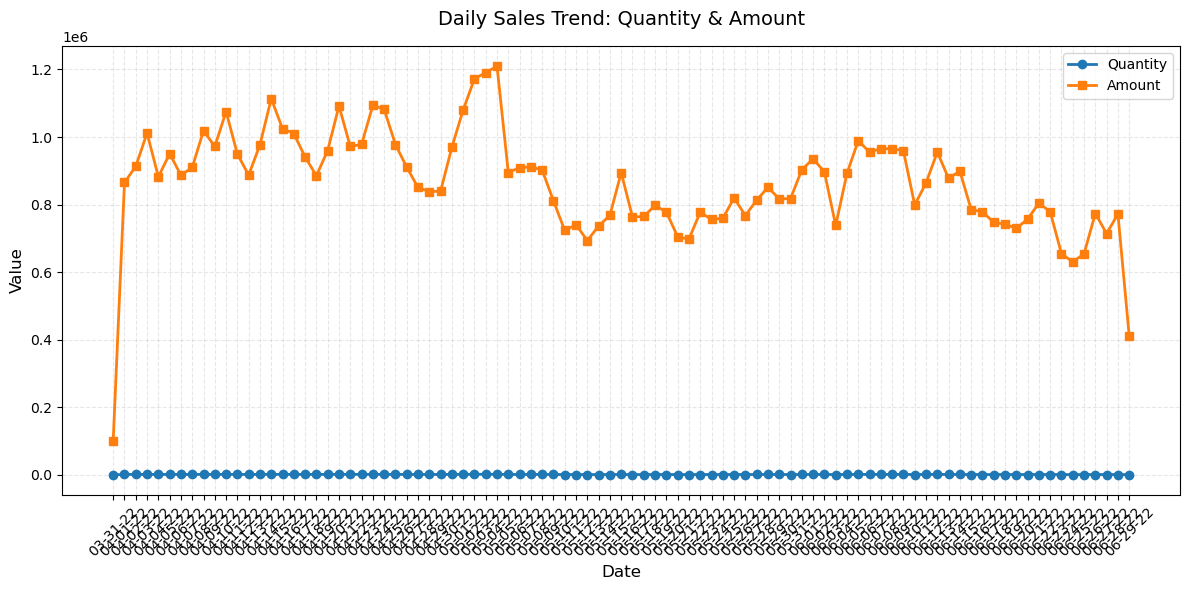

In [92]:

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# Plot both lines
plt.plot(data_daywise['Date'], data_daywise['Qty'], 
         marker='o', linewidth=2, label='Quantity', color='#1f77b4')

plt.plot(data_daywise['Date'], data_daywise['Amount'], 
         marker='s', linewidth=2, label='Amount', color='#ff7f0e')

# Formatting
plt.title('Daily Sales Trend: Quantity & Amount', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

/var/folders/y_/9_nph4511bzfw73_qcf3wry00000gn/T/ipykernel_26441/2237671321.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_daywise['Date'] = pd.to_datetime(data_daywise['Date'])


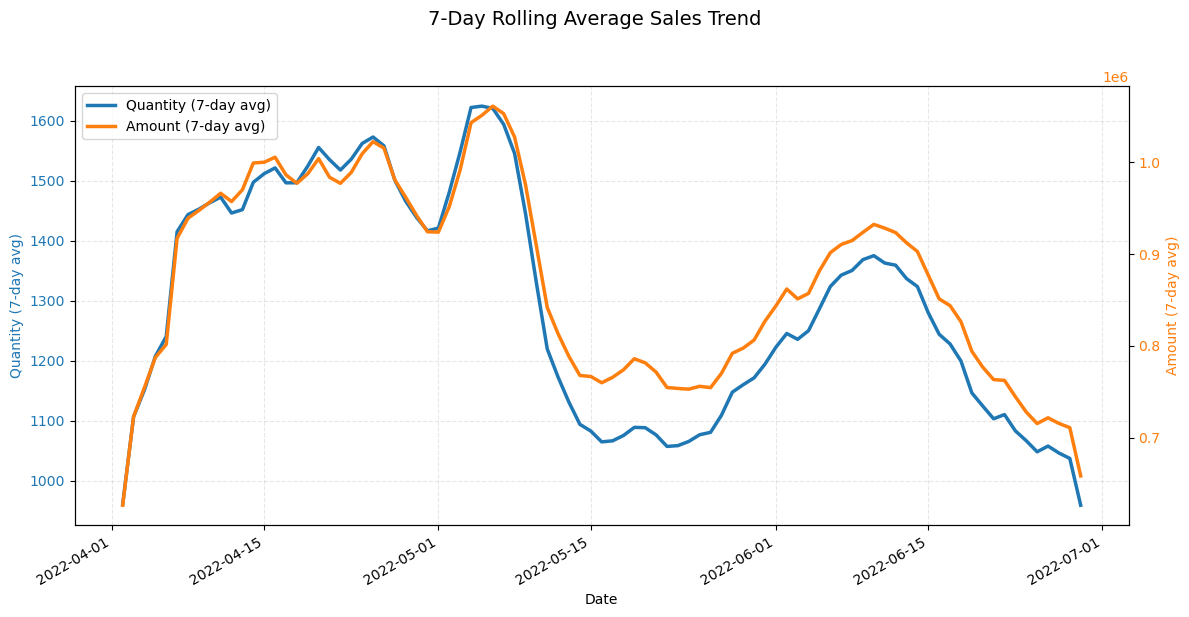

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure Date is datetime
data_daywise['Date'] = pd.to_datetime(data_daywise['Date'])

# Sort just in case
data_daywise = data_daywise.sort_values('Date').reset_index(drop=True)

# Calculate 7-day rolling mean (smooth curve)
data_rolling = data_daywise.copy()
data_rolling['Qty_7d_avg']   = data_daywise['Qty'].rolling(window=7, min_periods=3).mean()
data_rolling['Amount_7d_avg'] = data_daywise['Amount'].rolling(window=7, min_periods=3).mean()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Quantity (left axis)
ax1.plot(data_rolling['Date'], data_rolling['Qty_7d_avg'], 
         linewidth=2.5, label='Quantity (7-day avg)', color='#1f77b4')
ax1.set_xlabel('Date')
ax1.set_ylabel('Quantity (7-day avg)', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3, linestyle='--')

# Amount (right axis)
ax2 = ax1.twinx()
ax2.plot(data_rolling['Date'], data_rolling['Amount_7d_avg'], 
         linewidth=2.5, label='Amount (7-day avg)', color='#ff7f0e')
ax2.set_ylabel('Amount (7-day avg)', color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Title & legend
fig.suptitle('7-Day Rolling Average Sales Trend', fontsize=14, y=1.02)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.autofmt_xdate()   # nice date formatting
plt.tight_layout()
plt.show()

In [94]:
#classify customers based on their total spending

In [95]:
#product category analysis

In [96]:
category_summary = category_summary.reset_index()

In [97]:
category_summary=data.groupby('Category').agg({'Qty':'sum','Amount':'sum','SKU':'nunique','Order ID': 'nunique'})
category_summary.columns = ['Total_Qty', 'Total_Amount', 'Unique_SKUs', 'Unique_Orders']
category_summary.sort_values('Total_Amount', ascending=False).reset_index()


,Category,Total_Qty,Total_Amount,Unique_SKUs,Unique_Orders
0,Set,45289,39204124.03,2490,47845
1,kurta,45045,21299546.70,2927,46561
2,Western Dress,13943,11216072.69,458,14994
3,Top,9903,5347792.30,791,10155
4,Ethnic Dress,1053,791217.66,94,1148
5,Blouse,863,458408.18,153,897
6,Bottom,398,150667.98,201,410
7,Saree,152,123933.76,78,144
8,Dupatta,3,915.00,3,2


In [98]:
category_summary

,Total_Qty,Total_Amount,Unique_SKUs,Unique_Orders
Category,,,,
Blouse,863,458408.18,153,897
Bottom,398,150667.98,201,410
Dupatta,3,915.00,3,2
Ethnic Dress,1053,791217.66,94,1148
Saree,152,123933.76,78,144
Set,45289,39204124.03,2490,47845
Top,9903,5347792.30,791,10155
Western Dress,13943,11216072.69,458,14994
kurta,45045,21299546.70,2927,46561


In [100]:
category_summary = category_summary.reset_index()

In [101]:
# Average Order Value per category
category_summary['AOV'] = (category_summary['Total_Amount'] / category_summary['Unique_Orders']).round(2)

# Average price per unit sold
category_summary['Avg_Price_Per_Unit'] = (category_summary['Total_Amount'] / category_summary['Total_Qty']).round(2)

# Percentage of total sales
category_summary['%_of_Total_Amount'] = (category_summary['Total_Amount'] / category_summary['Total_Amount'].sum() * 100).round(2)

# Top categories by contribution
category_summary[['Category', 'Total_Amount', '%_of_Total_Amount', 'Total_Qty', 'AOV', 'Unique_SKUs']]

,Category,Total_Amount,%_of_Total_Amount,Total_Qty,AOV,Unique_SKUs
0,Blouse,458408.18,0.58,863,511.05,153
1,Bottom,150667.98,0.19,398,367.48,201
2,Dupatta,915.00,0.00,3,457.50,3
3,Ethnic Dress,791217.66,1.01,1053,689.21,94
4,Saree,123933.76,0.16,152,860.65,78
5,Set,39204124.03,49.88,45289,819.40,2490
6,Top,5347792.30,6.80,9903,526.62,791
7,Western Dress,11216072.69,14.27,13943,748.04,458
8,kurta,21299546.70,27.10,45045,457.45,2927


In [102]:
# Get unique categories (as a list)
unique_categories = data['Category'].unique()
print(unique_categories)

['Set' 'kurta' 'Western Dress' 'Top' 'Ethnic Dress' 'Bottom' 'Saree'
 'Blouse' 'Dupatta']


In [107]:
category_summary.sort_values(by='Total_Qty',ascending=False)

,Category,Total_Qty,Total_Amount,Unique_SKUs,Unique_Orders,AOV,Avg_Price_Per_Unit,%_of_Total_Amount
5,Set,45289,39204124.03,2490,47845,819.40,865.64,49.88
8,kurta,45045,21299546.70,2927,46561,457.45,472.85,27.10
7,Western Dress,13943,11216072.69,458,14994,748.04,804.42,14.27
6,Top,9903,5347792.30,791,10155,526.62,540.02,6.80
3,Ethnic Dress,1053,791217.66,94,1148,689.21,751.39,1.01
0,Blouse,863,458408.18,153,897,511.05,531.18,0.58
1,Bottom,398,150667.98,201,410,367.48,378.56,0.19
4,Saree,152,123933.76,78,144,860.65,815.35,0.16
2,Dupatta,3,915.00,3,2,457.50,305.00,0.00


/var/folders/y_/9_nph4511bzfw73_qcf3wry00000gn/T/ipykernel_26441/3943012846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='Total_Amount', y='Category', palette='viridis')


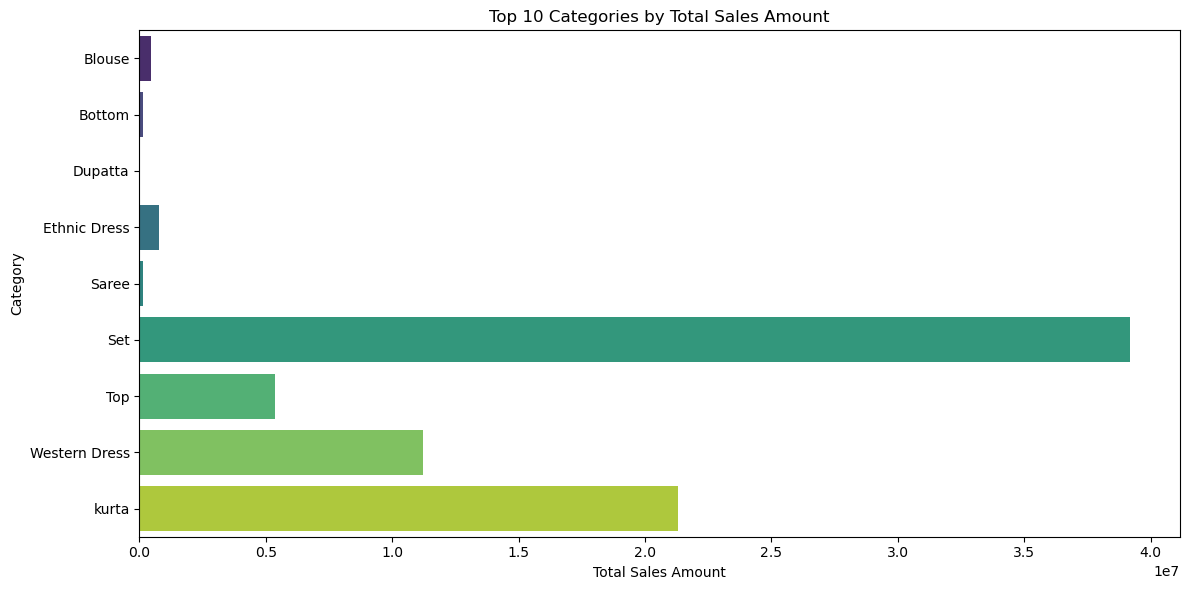

In [60]:
import seaborn as sns
top_n = 10
top_categories = category_summary.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='Total_Amount', y='Category', palette='viridis')
plt.title(f'Top {top_n} Categories by Total Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [109]:
# Group by Category and SKU, aggregate, then get top N per category
top_n = 3

top_skus_per_category = (
    data.groupby(['Category', 'SKU'])
    .agg({
        'Qty': 'sum',
        'Amount': 'sum'
    })
    .reset_index()
    .sort_values(['Category', 'Amount'], ascending=[True, False])  # Sort by Amount descending within each category
    .groupby('Category')
    .head(top_n)
    .round(2)
)

# Optional: Add rank column
top_skus_per_category['Rank'] = top_skus_per_category.groupby('Category').cumcount() + 1

print(top_skus_per_category[['Category', 'Rank', 'SKU', 'Qty', 'Amount']])

           Category  Rank                         SKU  Qty     Amount
139          Blouse     1                  J0217-BL-M   35   24288.90
138          Blouse     2                  J0217-BL-L   30   20908.33
140          Blouse     3                  J0217-BL-S   27   20670.99
274          Bottom     1                 BTM038-PP-S    6    2989.90
284          Bottom     2              BTM039-PP-XXXL    7    2862.86
279          Bottom     3                 BTM039-PP-M    5    2828.58
354         Dupatta     1                      DPT032    1     305.00
355         Dupatta     2                      DPT041    1     305.00
356         Dupatta     3                      DPT052    1     305.00
365    Ethnic Dress     1                 J0006-SET-M   84   73072.95
367    Ethnic Dress     2                J0006-SET-XL   60   51465.48
366    Ethnic Dress     3                 J0006-SET-S   57   50827.04
490           Saree     1                      SAR069   12   13124.57
487           Saree 

In [ ]:
#classify customers based on their total spending

In [68]:
customer_total=data.copy()
customer_total.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [69]:
import pandas as pd
import numpy as np

# 1. Create proxy customer ID (since real customer_id is missing)
data['customer_proxy'] = (
    data['ship-city'].fillna('Unknown') + '|' +
    data['ship-state'].fillna('Unknown') + '|' +
    data['ship-postal-code'].astype(str).fillna('Unknown')
)

# 2. Optional: Filter only successful orders (recommended)
df_success = data[data['Status'].isin(['Shipped', 'Delivered'])].copy()

# 3. Aggregate total spending per customer
customer_total = df_success.groupby('customer_proxy').agg(
    Total_Spending=('Amount', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    First_Order=('Date', 'min'),
    Last_Order=('Date', 'max'),
    Avg_Order_Value=('Amount', 'mean')
).reset_index()

customer_total['Total_Spending'] = customer_total['Total_Spending'].round(2)
customer_total['Avg_Order_Value'] = customer_total['Avg_Order_Value'].round(2)

print(customer_total.head())

                                      customer_proxy  Total_Spending  \
0        (Via Cuncolim)Quepem,South Goa|GOA|403703.0          1163.0   
1                      ,HYDERABAD|TELANGANA|500038.0           563.0   
2  ,raibarely road faizabad (Ayodhya)|UTTAR PRADE...          1122.0   
3                   ..katra|JAMMU & KASHMIR|182301.0           641.0   
4                .Gannavaram|ANDHRA PRADESH|521101.0           832.0   

   Order_Count First_Order Last_Order  Avg_Order_Value  
0            1    06-27-22   06-27-22           1163.0  
1            1    04-22-22   04-22-22            563.0  
2            1    06-11-22   06-11-22           1122.0  
3            1    05-09-22   05-09-22            641.0  
4            1    05-20-22   05-20-22            832.0  


In [112]:
def classify_spending(amount):
    if pd.isna(amount) or amount <= 0:
        return 'No Purchase / Inactive'
    elif amount < 1000:
        return 'Low Spender (< ₹1,000)'
    elif amount < 5000:
        return 'Medium Spender (₹1,000 - 4,999)'
    elif amount < 15000:
        return 'High Spender (₹5,000 - 14,999)'
    elif amount < 50000:
        return 'Premium Spender (₹15,000 - 49,999)'
    else:
        return 'VIP / Whale (₹50,000+)'

customer_total['Spending_Tier'] = customer_total['Total_Spending'].apply(classify_spending)

# Summary table
spending_summary = customer_total.groupby('Spending_Tier').agg(
    Customer_Count=('customer_proxy', 'count'),
    Total_Revenue=('Total_Spending', 'sum'),
    Avg_Spending=('Total_Spending', 'mean'),
    Avg_Orders=('Order_Count', 'mean'),
    Customers=('customer_proxy', lambda x: len(x)/len(customer_total)*100)
).round(1)

spending_summary = spending_summary.sort_values('Total_Revenue', ascending=False)
spending_summary['%Revenue'] = (spending_summary['Total_Revenue'] / spending_summary['Total_Revenue'].sum() * 100).round(1)

spending_summary

,Customer_Count,Total_Revenue,Avg_Spending,Avg_Orders,Customers,%Revenue
Spending_Tier,,,,,,
"Premium Spender (₹15,000 - 49,999)",532,13628308.0,25617.1,36.6,3.8,27.1
"VIP / Whale (₹50,000+)",121,10976199.0,90712.4,129.1,0.9,21.8
"Medium Spender (₹1,000 - 4,999)",5127,10775599.0,2101.7,2.9,36.3,21.4
"High Spender (₹5,000 - 14,999)",1273,10690639.0,8398.0,11.9,9.0,21.2
"Low Spender (< ₹1,000)",7061,4253510.0,602.4,1.1,50.0,8.5
No Purchase / Inactive,12,0.0,0.0,10.4,0.1,0.0


In [75]:
# Calculate key percentiles
percentiles = customer_total['Total_Spending'].quantile([0, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
print("Spending Percentiles (₹):\n", percentiles)

def classify_by_percentile(amount):
    if pd.isna(amount) or amount <= 0:
        return 'No Purchase'
    elif amount <= percentiles[0.50]:
        return 'Bottom 50% - Mass Market'
    elif amount <= percentiles[0.80]:
        return 'Middle 30% - Core Customers'
    elif amount <= percentiles[0.90]:
        return 'Top 10-20% - High Value'
    elif amount <= percentiles[0.95]:
        return 'Top 5-10% - Very High Value'
    elif amount <= percentiles[0.99]:
        return 'Top 1-5% - Elite'
    else:
        return 'Top 1% - Whales / Power Customers'

customer_total['Spending_Segment'] = customer_total['Total_Spending'].apply(classify_by_percentile)

# Summary
customer_total['Spending_Segment'].value_counts(normalize=True) * 100
print("\nRevenue contribution by segment:")
customer_total.groupby('Spending_Segment')['Total_Spending'].sum().sort_values(ascending=False)

Spending Percentiles (₹):
 0.00         0.00
0.50       999.00
0.80      3120.00
0.90      7094.50
0.95     14064.00
0.99     46092.75
1.00    338101.00
Name: Total_Spending, dtype: float64

Revenue contribution by segment:


Spending_Segment
Top 1-5% - Elite                     13410027.0
Top 1% - Whales / Power Customers    11980635.0
Middle 30% - Core Customers           7237723.0
Top 5-10% - Very High Value           6873137.0
Top 10-20% - High Value               6569223.0
Bottom 50% - Mass Market              4253510.0
No Purchase                                 0.0
Name: Total_Spending, dtype: float64

In [76]:
# Sort customers by spending descending
sorted_customers = customer_total.sort_values('Total_Spending', ascending=False).reset_index(drop=True)

# Cumulative percentage
sorted_customers['Cumulative_Revenue'] = sorted_customers['Total_Spending'].cumsum()
sorted_customers['Cumulative_%'] = (sorted_customers['Cumulative_Revenue'] / sorted_customers['Total_Spending'].sum() * 100)

# Find how many customers make 80% of revenue
pareto_80 = sorted_customers[sorted_customers['Cumulative_%'] >= 80].index[0] + 1
print(f"Top {pareto_80} customers ({pareto_80/len(customer_total):.1%} of total) generate ≈80% of revenue")

Top 3328 customers (23.6% of total) generate ≈80% of revenue


/var/folders/y_/9_nph4511bzfw73_qcf3wry00000gn/T/ipykernel_26441/1599799092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_total, y='Spending_Tier', order=[


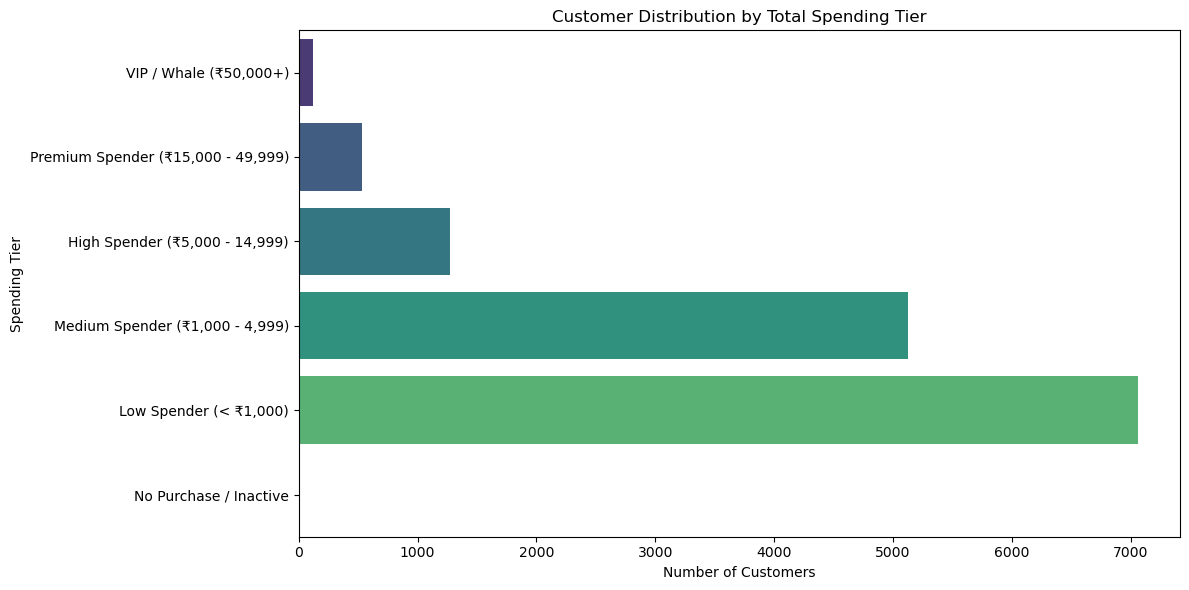

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=customer_total, y='Spending_Tier', order=[
    'VIP / Whale (₹50,000+)',
    'Premium Spender (₹15,000 - 49,999)',
    'High Spender (₹5,000 - 14,999)',
    'Medium Spender (₹1,000 - 4,999)',
    'Low Spender (< ₹1,000)',
    'No Purchase / Inactive'
], palette='viridis')

plt.title('Customer Distribution by Total Spending Tier')
plt.xlabel('Number of Customers')
plt.ylabel('Spending Tier')
plt.tight_layout()
plt.show()